In [7]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"   # 只让第3块物理卡可见
# os.environ["CUDA_VISIBLE_DEVICES"] = "3,5"  # 让第4和第6块卡可见（多卡）

import torch, faiss

device = torch.device("cuda:0")
torch.cuda.set_device(device)




torch 可见卡数: 1
当前卡: 0 NVIDIA GeForce RTX 3090
FAISS 可见 GPU 数: 8


In [9]:
import os
import torch
import pandas as pd
import pyterrier as pt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from pyterrier.measures import *
# Initialize PyTerrier
if not pt.started():
    pt.init()


/tmp/ipykernel_3182830/2053532107.py:9: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


In [10]:
# Step 1: Load dataset
dataset = pt.get_dataset("msmarco_passage")
topics19 = dataset.get_topics("test-2019")
qrels2019 = dataset.get_qrels("test-2019")
topics2019 = topics19.merge(qrels2019, on = "qid")[["qid","query"]].drop_duplicates()
topics20 = dataset.get_topics("test-2020")
qrels2020 = dataset.get_qrels("test-2020")
topics2020 = topics20.merge(qrels2020, on = "qid")[["qid","query"]].drop_duplicates()
topics_dlhard = pt.get_dataset('irds:msmarco-passage/trec-dl-hard').get_topics()
qrels_dlhard = pt.get_dataset('irds:msmarco-passage/trec-dl-hard').get_qrels()

The centroids candidate expansion, One potentially easy starting point would be to use the IDs to recover from recall problems without modifying the final query directly:
 
- Step 1: [Normal retrieval stuff]
- Step 2: Look up token cluster IDs of top results
- Step 3: Identify **important** cluster IDs that were not part of the ones that were used for retrieval. (How to define importance here? - - Perhaps most frequent?)
- Step 4: Retrieve and score the documents from those clusters using the original query representation.
- Step 5: (Repeat steps 2-4 until convergence?)

In [52]:
from pyterrier_colbert.ranking import ColBERTv2Index
import time
start_time = time.time()
colbert_model_path = '/data2/wangxiao/pyterrier_colbert/colbertv2.0'
# bm25_terrier_stemmed = pt.BatchRetrieve.from_dataset('vaswani', 'terrier_stemmed', wmodel='BM25')
factory_a = ColBERTv2Index(colbert=colbert_model_path, 
                         index_location="/data2/wangxiao/pyterrier_colbert2/msmarco_psg_v1_index/2bits/indexes/2bits/",
                           plaid_mode=True, ncells=1, centroid_score_threshold=0.5, ndocs=256) 
# plaid_e2e = factory.plaid_end_to_end(k=1000)
end_time = time.time()

elapsed_time = end_time - start_time
print(f" V2 retrieval time: {elaapsed_time:.2f} seconds")

[Aug 28, 14:23:07] #> Loading codec...
[Aug 28, 14:23:07] #> Loading IVF...
[Aug 28, 14:23:08] #> Loading doclens...


100%|███████████████████████████████████████| 354/354 [00:00<00:00, 1273.53it/s]


[Aug 28, 14:23:09] #> Loading codes and residuals...


100%|█████████████████████████████████████████| 354/354 [00:16<00:00, 21.24it/s]


NameError: name 'elaapsed_time' is not defined

In [ ]:
from pyterrier_colbert.ranking import ColBERTv2Index
import time
start_time = time.time()
colbert_model_path = '/data2/wangxiao/pyterrier_colbert/colbertv2.0'
# bm25_terrier_stemmed = pt.BatchRetrieve.from_dataset('vaswani', 'terrier_stemmed', wmodel='BM25')
factory_b = ColBERTv2Index(colbert=colbert_model_path, 
                         index_location="/data2/wangxiao/pyterrier_colbert2/msmarco_psg_v1_index/2bits/indexes/2bits/",
                           plaid_mode=True, ncells=2, centroid_score_threshold=0.45, ndocs=1024) 
# plaid_e2e = factory.plaid_end_to_end(k=1000)
end_time = time.time()

elapsed_time = end_time - start_time
print(f" V2 retrieval time: {elaapsed_time:.2f} seconds")

In [12]:
from pyterrier_colbert.ranking import ColBERTv2Index
import time
start_time = time.time()
colbert_model_path = '/data2/wangxiao/pyterrier_colbert/colbertv2.0'
# bm25_terrier_stemmed = pt.BatchRetrieve.from_dataset('vaswani', 'terrier_stemmed', wmodel='BM25')
factory = ColBERTv2Index(colbert=colbert_model_path, 
                         index_location="/data2/wangxiao/pyterrier_colbert2/msmarco_psg_v1_index/2bits/indexes/2bits/",
                           plaid_mode=True, ncells=4, centroid_score_threshold=0.4, ndocs=4096) 
# plaid_e2e = factory.plaid_end_to_end(k=1000)
end_time = time.time()

elapsed_time = end_time - start_time
print(f" V2 retrieval time: {elapsed_time:.2f} seconds")

[Aug 28, 13:25:13] #> Loading codec...
[Aug 28, 13:25:14] Loading decompress_residuals_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


/data2/wangxiao/anaconda3/envs/v2/lib/python3.8/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


[Aug 28, 13:25:14] Loading packbits_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


/data2/wangxiao/anaconda3/envs/v2/lib/python3.8/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


[Aug 28, 13:25:14] #> Loading IVF...
[Aug 28, 13:25:18] #> Loading doclens...


100%|████████████████████████████████████████| 354/354 [00:00<00:00, 465.68it/s]


[Aug 28, 13:25:20] #> Loading codes and residuals...


100%|█████████████████████████████████████████| 354/354 [01:28<00:00,  3.99it/s]


 V2 retrieval time: 199.13 seconds


# Test

In [20]:
import pandas as pd, torch, torch.nn.functional as F
def l2(x): return F.normalize(x, p=2, dim=-1)
dfq = topics2019.head(1)
qid, qtext = dfq.iloc[0]["qid"], dfq.iloc[0]["query"]
Q = factory.searcher.encode([qtext]).squeeze(0).to(torch.float32)
device = Q.device; Q = l2(Q)
Q

tensor([[ 0.0619,  0.0219, -0.0458,  ...,  0.1309,  0.1390,  0.0535],
        [ 0.1165,  0.1143, -0.0283,  ...,  0.0239,  0.0910, -0.0401],
        [-0.0466,  0.0872, -0.1657,  ...,  0.0678,  0.0155, -0.0288],
        ...,
        [ 0.0558, -0.1101,  0.2232,  ...,  0.0876,  0.1010,  0.0478],
        [ 0.0567, -0.1037,  0.2161,  ...,  0.0866,  0.0976,  0.0534],
        [ 0.0447, -0.0935,  0.1794,  ...,  0.0930,  0.1051,  0.0609]],
       device='cuda:0')

In [28]:
ranker = factory.searcher.ranker
cfg    = factory.searcher.config
C      = ranker.codec.centroids                     # [C, dim]
lookup_pids = _ivf_lookup_pids(ranker)  
embS = ranker.embeddings_strided

In [30]:
k=1000

base_pids, _, base_scores = factory.searcher.dense_search(Q.unsqueeze(0), k=k)
base_pids_list = base_pids#.tolist()
base_scores_t  = torch.tensor(base_scores, device=device, dtype=torch.float32)

# 2. estimate used cells (PLAID ncells)
C_dev = C.to(device=device, dtype=torch.float32)
sims  = (C_dev @ Q.T).max(dim=1).values
used  = set(torch.topk(sims, k=min(cfg.ncells, C_dev.size(0))).indices.tolist())
used

{25450, 144122, 165187, 220038}

In [44]:
prf_k=3
prf_pids = base_pids_list[:min(prf_k, len(base_pids_list))]
prf_pids

[2928707, 8182159, 1960255]

In [134]:
merged_pids   = list(base_pids)
merged_scores = torch.tensor(base_scores, device=device, dtype=torch.float32)
pid2score     = {int(pid): float(s) for pid, s in zip(merged_pids, merged_scores.tolist())}
# pid2score

In [102]:
# pid2score = 
freq, sfreq, qa_map,sizes = {},{},{},{}
D_packed, D_lens = embS.lookup_pids(prf_pids)  # given the prf_pid, fetch its token embeddings and the offset.
start = 0
for pid, L in zip(prf_pids, D_lens.tolist()):
    L = int(L);  w = pid2score.get(int(pid), 0.0)
    print("prf_doc token length:",L, "prf_doc initial maxsim score:",w)
    if L == 0: continue
    D = D_packed[start:start+L].to(device=Q.device, dtype=torch.float32)
    print(D.shape)
    print(C_dev.shape)
    assign = (C_dev @ D.T).argmax(dim=0)          # [L] locate the maxsim scored centroids
    print(assign.shape)
    
    for c in assign.tolist(): # for all the identified centroids, we calcualte their importance, freq for instance. 
    #     print(c)
        freq[c]  = freq.get(c, 0)    + 1
    # print(freq)
    #     # sfreq[c] = sfreq.get(c, 0.0) + w
    start += L
cand_cids = list(freq.keys())
print(len(cand_cids))
            
ids = torch.tensor(cand_cids, dtype=torch.long, device=Q.device)
print(">>>>>>",len(ids))
# print(cand_cids[:3])
qa_vals = (C_dev.index_select(0, ids) @ Q.T).max(dim=1).values.cpu().numpy().tolist() 
print(">>>test",(C_dev.index_select(0,ids[:1])@ Q.T).shape)
qa_test =(C_dev.index_select(0,ids[:3])@ Q.T).max(dim=1).values
print(qa_test.shape, qa_test)
# print(len(qa_vals)
# for cid, qa in zip(cand_cids, qa_vals):
#      qa_map[cid] = float(qa)
# qa_map
for c in cand_cids[:3]:
    _, lens = lookup_pids([int(c)])
    sizes[c] = int(lens[0])

prf_doc token length: 68 prf_doc initial maxsim score: 28.046875
torch.Size([68, 128])
torch.Size([262144, 128])
torch.Size([68])
prf_doc token length: 73 prf_doc initial maxsim score: 27.90625
torch.Size([73, 128])
torch.Size([262144, 128])
torch.Size([73])
prf_doc token length: 68 prf_doc initial maxsim score: 27.875
torch.Size([68, 128])
torch.Size([262144, 128])
torch.Size([68])
127
>>>>>> 127
>>>test torch.Size([1, 32])
torch.Size([3]) tensor([0.4963, 0.1307, 0.1250], device='cuda:0')


In [88]:
cand_cids[:3]

[99066, 86639, 103041]

In [89]:
lookup_pids([99066])

(tensor([   2925,   26124,   41613,  ..., 8820525, 8834651, 8839668],
        device='cuda:0', dtype=torch.int32),
 tensor([1189]))

In [56]:
(0.8679-0.8389)/0.8389

0.03456907855525095

# Parameter study: dense_prf_k
-> prf_k =3 is the best

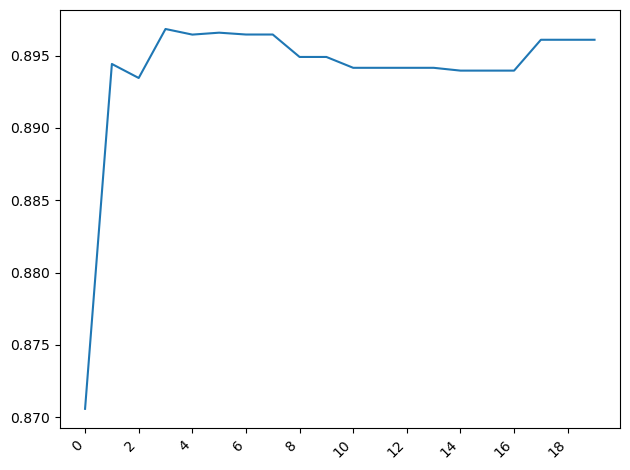

In [21]:
df = res_m
ax = plt.figure().gca()
ax.plot(df.index, df['R(rel=2)@1000'])

# 只显示一部分刻度，避免太挤
step = max(1, len(df)//10)       # 约 10 个刻度
ax.set_xticks(df.index[::step])
ax.set_xticklabels(df.index[::step], rotation=45, ha='right')

plt.tight_layout(); plt.show()


In [24]:
plaid_e2e = factory.plaid_end_to_end(k=1000)
systems = [plaid_e2e]
names = ['plaid']
for  m in range(2,101,2):
    systems.append(centroid_recall_boost(factory, prf_k=3, m_extra=m, rounds=1,k=1000))
    names.append(f'plaid_centroid_bst_m={m}')
res_m = pt.Experiment(
    systems,
    topics2019, qrels2019,
    eval_metrics = [RR(rel=2), nDCG@10, nDCG@100, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=names, verbose = True
)
res_m


pt.Experiment: 100%|████████████████████████| 51/51 [16:49<00:00, 19.80s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid,0.893411,0.738266,0.683256,0.509709,0.288459,0.665104,0.870589
1,plaid_centroid_bst_m=2,0.893411,0.738266,0.683473,0.509905,0.288459,0.665385,0.878903
2,plaid_centroid_bst_m=4,0.893411,0.738266,0.683772,0.510278,0.288459,0.665385,0.888109
3,plaid_centroid_bst_m=6,0.893411,0.738266,0.683772,0.510434,0.288459,0.665385,0.888753
4,plaid_centroid_bst_m=8,0.893411,0.738266,0.683772,0.510590,0.288459,0.665385,0.892197
5,plaid_centroid_bst_m=10,0.893411,0.738266,0.683772,0.510973,0.288459,0.665385,0.892644
6,plaid_centroid_bst_m=12,0.893411,0.738266,0.684020,0.511363,0.288459,0.665665,0.894815
7,plaid_centroid_bst_m=14,0.893411,0.738266,0.684375,0.511675,0.288459,0.666415,0.897478
8,plaid_centroid_bst_m=16,0.893411,0.738266,0.684375,0.511613,0.288459,0.666415,0.896152
9,plaid_centroid_bst_m=18,0.893411,0.738266,0.684389,0.511573,0.288459,0.666415,0.896025


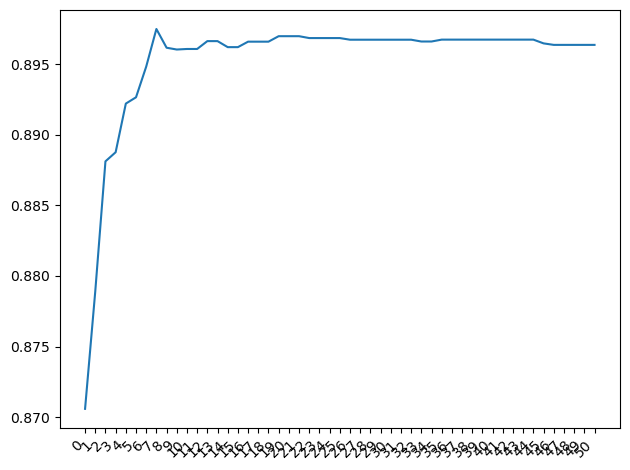

In [27]:
df = res_m
ax = plt.figure().gca()
ax.plot(df.index, df['R(rel=2)@1000'])

# 只显示一部分刻度，避免太挤
# step = max(1, len(df)//10)       # 约 10 个刻度
step=1
ax.set_xticks(df.index[::step])
ax.set_xticklabels(df.index[::step], rotation=45, ha='right')

plt.tight_layout(); plt.show()


In [37]:

index_path = "/data2/wangxiao/pyterrier_colbert2/passage_index/data.properties"
index = pt.IndexFactory.of(index_path)
print(index.getCollectionStatistics().toString())


# 用 BM25 检索
br = pt.BatchRetrieve(index, wmodel="BM25")

21:57:06.932 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 1.9 GiB of memory would be required.
Number of documents: 8841823
Number of terms: 1170682
Number of postings: 215238456
Number of fields: 0
Number of tokens: 288759529
Field names: []
Positions:   false



/tmp/ipykernel_3158377/2463052583.py:7: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  br = pt.BatchRetrieve(index, wmodel="BM25")


# Variants of Centroid Recall Boost method
## 1. frequency of centroid ids:
- intuition: the more frequent of the terms in PRF docs, the more likely they are to be relevant to the query (similar to Rocchio); different in our case, we apply instead of terms, we apply for the token cluster centroid.
> parameter:
> - prf_k: how many returned docs are used as the seed to mine extra centroids;
> - m_extra:how many new exta centroids are used?
> - further for effiency control: instead of searching all the pids corresponding to a centroid, we can only search a certarn number? randomly
> - TODO: can we merge the centroids into the candidate pool, and followed with plaid centroid-ineractin and pruning? seems we don't need. as accuracy doesn't hurt.

## 2. mmr:
- intuition: beyond frequency, we can also employ the score
> parameter:
> - mmr_lamda: controls the centroid similarity to the query and the selected centroids. mmr_lambda*qa - (1-mmr_lambda)*sims
> - 

In [58]:
import pandas as pd, numpy as np, torch, torch.nn.functional as F
def l2(x): return F.normalize(x, p=2, dim=-1)
import logging

def _ivf_lookup_pids(ranker):
    """
    requirements: index contains: ivf.pid.pt file
    Returns  lookup_pids(c_ids) -> (packed_pids: LongTensor, lengths: LongTensor)
    """
    ivf_pid = getattr(ranker, 'ivf_pid', None)
    tbl = ivf_pid if ivf_pid is not None else ranker.ivf  # 两者都返回 PID

    def lookup_pids(c_ids):
        return tbl.lookup(c_ids)

    return lookup_pids
def _hybrid(dfq, pid2score, merged_pids, sparse_retriever, prf_k_dense, prf_k_sparse,w_dense,w_sparse, hybrid ):
    assert len(dfq) == 1
    dense_head = merged_pids[:min(prf_k_dense, len(merged_pids))] 
    prf_pid_set = set(int(pid) for pid in dense_head)
    if (sparse_retriever is not None) and (prf_k_sparse and prf_k_sparse > 0):
        sparse_df = sparse_retriever(dfq).head(prf_k_sparse)[["docno", "score"]].reset_index(drop=True)
        sparse_pairs = []
        for _, row_s in sparse_df.iterrows():
                sparse_pairs.append((int(row_s["docno"]), float(row_s["score"])))

        if hybrid == 'union':
            for pid, _ in sparse_pairs:
                prf_pid_set.add(pid)

        elif hybrid == 'interleave':
            dense_pairs  = [(int(pid), float(pid2score.get(int(pid), 0.0))) for pid in dense_head]
            inter, i, j = [], 0, 0
            while (i < len(dense_pairs) or j < len(sparse_pairs)) and len(inter) < (prf_k_dense + prf_k_sparse):
                if i < len(dense_pairs):
                    inter.append(dense_pairs[i]); i += 1
                if j < len(sparse_pairs):
                    inter.append(sparse_pairs[j]); j += 1
            prf_pid_set = set(pid for pid, _ in inter)

        elif hybrid == 'weighted':
            # 把两路分数融合进 pid2score（便于后续 scorefreq / mix 策略使用）
            for pid in dense_head:
                pid = int(pid)
                pid2score[pid] = max(pid2score.get(pid, 0.0), w_dense * float(pid2score.get(pid, 0.0)))
            for pid, s in sparse_pairs:
                pid2score[pid] = max(pid2score.get(pid, 0.0), w_sparse * s)
            for pid, _ in sparse_pairs:
                prf_pid_set.add(pid)
        else:
            # 回退到 union
            for pid, _ in sparse_pairs:
                prf_pid_set.add(pid)
    # PRF 列表：保持稳定顺序（先 dense，再补 sparse）
    prf_pids = list(dense_head) + [pid for pid in prf_pid_set if pid not in dense_head]
    return prf_pids
    
# ---- choose extra centroids (same strategies you already had) ----
def _mine_stats(Q, prf_pids, C_dev, pid2score, embS,lookup_pids):
    # build freq, qa, size for candidate cells from PRF pids
    freq, qa_map, sizes = {}, {}, {}
    if prf_pids:
        D_packed, D_lens = embS.lookup_pids(prf_pids)  # given the prf_pid, fetch its token embeddings and the offset.
        start = 0
        for pid, L in zip(prf_pids, D_lens.tolist()):
            L = int(L);  w = pid2score.get(int(pid), 0.0)
            if L == 0: continue
            D = D_packed[start:start+L].to(device=Q.device, dtype=torch.float32)
            assign = (C_dev @ D.T).argmax(dim=0)          # [L]
            for c in assign.tolist():
                freq[c]  = freq.get(c, 0)    + 1
            start += L
    cand_cids = list(freq.keys())
    if not cand_cids:
        return pd.DataFrame(columns=['cid','freq','qa','size'])
        
    cids = torch.tensor(cand_cids, dtype=torch.long, device=Q.device)
    # (C_embs @ Q.T).max(dim=1) the maxsim similarity to the query, similar to ncells, but find the most relevant centroid to a query token，
    #给每个簇心找它最像的 token”。如果据此再挑 top-K 簇心，就是全局选与某些查询 token 最接近的那些簇心，容易把配额集中在少数高相似 token 上，不保证覆盖所有查询要素。
    qa_vals = (C_dev.index_select(0, cids) @ Q.T).max(dim=1).values.cpu().numpy().tolist()
    for cid, qa in zip(cand_cids, qa_vals): qa_map[cid] = float(qa)
    for c in cand_cids:
        _, lens = lookup_pids([int(c)])
        sizes[c] = int(lens[0])
    rows = [{"cid":int(c), "freq":int(freq.get(c,0)),
             "qa":float(qa_map.get(c,0.0)), "size":int(sizes.get(c,0))} for c in cand_cids]
    return pd.DataFrame(rows)
        
def _select_extra_cells( stats_df, used_set, m, strat, C_dev, pid2score, mmr_lambda=0.7):
    cand = stats_df[~stats_df['cid'].isin(list(used_set))].copy() # obtain the new centroid ids
    if cand.empty: return []
    if strat == 'freq':
        return cand.sort_values('freq', ascending=False).head(m)['cid'].tolist()
    if strat == 'qa':
        return cand.sort_values('qa', ascending=False).head(m)['cid'].tolist()
    if strat == 'mmr':
        # MMR： diversification to the already selected mmr
        # \arg\max_i\ \lambda\,\text{rel}i-(1-\lambda)\max{j\in S}\text{sim}(i,j)，
        cand = cand.sort_values('qa', ascending=False).reset_index(drop=True)
        New_cids = torch.tensor(cand['cid'].tolist(), dtype=torch.long, device=C_dev.device)
        New_embs = C_dev.index_select(0, New_cids)
        qa = torch.tensor(cand['qa'].values, device=C_dev.device)
        chosen = []; chosen_New_embs = torch.zeros(0, New_embs.size(1), device=C_dev.device)
        for _ in range(min(m, len(cand))):
            if chosen_New_embs.shape[0] == 0:
                j = int(torch.argmax(qa).item())
            else:
                sims = (New_embs @ chosen_New_embs.T).max(dim=1).values
                score = mmr_lambda*qa - (1-mmr_lambda)*sims
                # print(f"mmr_lambda:{mmr_lambda}")
                j = int(torch.argmax(score).item())
            chosen.append(int(cand.iloc[j]['cid']))
            chosen_New_embs = torch.vstack([chosen_New_embs, New_embs[j:j+1]])
            qa[j] = -1e9
        return chosen
    return cand.sort_values('freq', ascending=False).head(m)['cid'].tolist()



def centroid_recall_boost_dynamic_hybrid(factory,
                                  strategy='freq',
                                  sparse_retriever = None,
                                  mmr_lambda=0.7,
                                  prf_k_dense=20,
                                  prf_k_sparse = 20,
                                  w_dense=1.0, w_sparse=0.5,   # 若使用 'weighted'，两路分数权重
                                  hybrid = 'weighted',
                                  m_extra=4, k=1000,
                                  max_rounds=8,
                                  consec_no_new_stop=2):
    """
      • Each round re-runs baseline dense_search(Q, k).
      • Builds a global pool of extra centroids (union over rounds).
      • Stops when *no NEW* extra centroids are mined in `consec_no_new_stop`
        consecutive rounds (or when max_rounds is hit).
    """
    ranker  = factory.searcher.ranker
    cfg     = factory.searcher.config
    C_cpu   = ranker.codec.centroids
    embS    = ranker.embeddings_strided
    lookup_pids = _ivf_lookup_pids(ranker)
    
        
    def _run(dfq):
        assert len(dfq) == 1
        qid, qtext = dfq.iloc[0]["qid"], dfq.iloc[0]["query"]

        # Query vector
        Q = factory.searcher.encode([qtext]).squeeze(0).to(torch.float32)
        Q = l2(Q)
        device = Q.device

        # 1. calcuate the used centroid pool
        C_dev = C_cpu.to(device=device, dtype=torch.float32)
        sims  = (C_dev @ Q.T).max(dim=1).values
        used  = set(torch.topk(sims, k=min(cfg.ncells, C_dev.size(0))).indices.tolist())
        pool_extra = set()                # grows across rounds
        no_new_rounds = 0

        # 2. Start with baseline dense_search (round 0), obtain the PRF pids
        pids, _, scores = factory.searcher.dense_search(Q.unsqueeze(0), k=k)
        merged_pids   = list(pids)
        merged_scores = torch.tensor(scores, device=device, dtype=torch.float32)
        pid2score     = {int(pid): float(s) for pid, s in zip(merged_pids, merged_scores.tolist())}

        for r in range(1, max_rounds + 1):
            # obtain the hybrid sparse and dense prf pids
            prf_pids = _hybrid(dfq, pid2score, merged_pids, sparse_retriever, prf_k_dense, prf_k_sparse, w_dense, w_sparse,hybrid)
 
            # using the prf_pids tokens to interact with the centroids and 
            # mine the importance score for the centroids
            
            stats = _mine_stats( Q, prf_pids, C_dev, pid2score,embS,lookup_pids)
            if stats.empty:
                break

            # pick extra cells and update the global pool
            extra = _select_extra_cells(stats, used, m_extra, strategy, C_dev, pid2score, mmr_lambda=mmr_lambda)
            # count only *new* extras
            newly_found = [c for c in extra if c not in pool_extra]
            if len(newly_found) == 0:
                no_new_rounds += 1
            else:
                no_new_rounds = 0
                pool_extra.update(newly_found)
            

            # stopping rule: no new extras in 2 consecutive rounds
            if no_new_rounds >= int(consec_no_new_stop):
                break
            

            # expand to PIDs from NEW extras only
            pid_chunks = []
            for c in newly_found:
                pp, ll = lookup_pids([int(c)])  # CPU
                n = int(ll[0])
                if n == 0: continue
                p = pp[:n]
                pid_chunks.append(p)
            if not pid_chunks:
                no_new_rounds += 1
                if no_new_rounds >= int(consec_no_new_stop): break
                continue

            new_pids_all = torch.cat(pid_chunks).long()  # CPU
            base_set = set(merged_pids)
            keep = [pid for pid in new_pids_all.tolist() if pid not in base_set]
            if not keep:
                no_new_rounds += 1
                if no_new_rounds >= int(consec_no_new_stop): break
                continue
            
            # score the *new* PIDs with full MaxSim
            new_pids = torch.tensor(keep, dtype=torch.long, device=device)
            scores2, pids2 = ranker.score_pids(cfg, Q.unsqueeze(0), new_pids, centroid_scores=None)

            # merge by best score per pid
            all_pids   = torch.tensor(merged_pids, device=device)
            all_scores = merged_scores.to(device)
            all_pids   = torch.cat([all_pids, pids2])
            all_scores = torch.cat([all_scores, scores2])

            best = {}
            for pid, s in zip(all_pids.tolist(), all_scores.tolist()):
                if pid not in best or s > best[pid]:
                    best[pid] = s
                    
            merged = sorted(best.items(), key=lambda x: x[1], reverse=True)[:k]
            merged_pids   = [pid for pid, _ in merged]
            merged_scores = torch.tensor([s for _, s in merged], device=device, dtype=torch.float32)
            pid2score.update({int(pid): float(s) for pid, s in merged})

        # final dataframe
        # print(f"The convergence round for strategy={strategy}: {r}")
        docnos = factory.docnos.fwd[merged_pids]
        return pd.DataFrame({
            "qid":   [dfq.iloc[0]["qid"]]*len(docnos),
            "docno": docnos,
            "round": r-int(consec_no_new_stop),
            "score": merged_scores[:len(docnos)].detach().cpu().numpy(),
            "rank":  list(range(1, len(docnos)+1))
        })

    import pyterrier as pt
    return pt.apply.by_query(_run, add_ranks=False)

In [15]:
bm25 = pt.BatchRetrieve.from_dataset('msmarco_passage', 'terrier_stemmed_text',num_results = 100)#, metadata = ['docno','text'])

/tmp/ipykernel_3182830/902329407.py:1: DeprecationWarning: Call to deprecated function (or staticmethod) from_dataset. (use pt.terrier.Retriever.from_dataset() instead) -- Deprecated since version 0.11.0.
  bm25 = pt.BatchRetrieve.from_dataset('msmarco_passage', 'terrier_stemmed_text',num_results = 100)#, metadata = ['docno','text'])


13:26:54.641 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 1.9 GiB of memory would be required.


# TREC 2019

In [48]:
boost_freq_hybrid = centroid_recall_boost_dynamic_hybrid(
    factory,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)
plaid_e2e = factory.plaid_end_to_end(k=1000)

boost_mmr_hybrid = centroid_recall_boost_dynamic_hybrid(
    factory,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)

from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e, boost_freq_hybrid, boost_mmr_hybrid],
    topics2019,
    qrels2019,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid-C','hybrid-freq','hybrid-mmr'],verbose = True
)

res1

pt.Experiment: 100%|██████████████████████████| 3/3 [00:40<00:00, 13.40s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid-C,0.893411,0.738266,0.683256,0.756087,0.509709,0.288459,0.665104,0.870589
1,hybrid-freq,0.893411,0.738266,0.683890,0.768979,0.511435,0.288459,0.665385,0.898920
2,hybrid-mmr,0.893411,0.738266,0.684375,0.766661,0.511623,0.288459,0.666415,0.889936


In [41]:
df = plaid_e2e(topics2019)

df_oracle = oracle_rerank_df(df, qrels2019, doc_col='docno')

# 评估（IDCG 用全量 qrels，因此不是 1）
pt.Evaluate(
    df_oracle, qrels2019,
    metrics = [RR(rel=2), nDCG@10, nDCG@100, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
)

{'RR(rel=2)': 1.0,
 'nDCG@10': 0.9930624288992396,
 'nDCG@100': 0.909215271648302,
 'AP(rel=2)': 0.8705885344548527,
 'R(rel=2)@10': 0.4429679100373483,
 'R(rel=2)@100': 0.8192111367800424,
 'R(rel=2)@1000': 0.8705885344548527}

In [46]:
boost_freq_hybrid_b = centroid_recall_boost_dynamic_hybrid(
    factory_b,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)

boost_mmr_hybrid_b = centroid_recall_boost_dynamic_hybrid(
    factory_b,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)
plaid_e2e_b = factory_b.plaid_end_to_end(k=1000)

from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e_b, boost_freq_hybrid_b,boost_mmr_hybrid_b ],
    topics2019,
    qrels2019,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid_B','hybrid-freq','hybrid-mmr'],verbose = True
    # 可选：控制 per-query 显示/保存等
)

res1

pt.Experiment:   0%|                                  | 0/3 [00:00<?, ?system/s]


#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: who is robert gray, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([ 101,    1, 2040, 2003, 2728, 3897,  102,  103,  103,  103,  103,  103,
         103,  103,  103,  103,  103,  103,  103,  103,  103,  103,  103,  103,
         103,  103,  103,  103,  103,  103,  103,  103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



pt.Experiment: 100%|██████████████████████████| 3/3 [00:35<00:00, 11.85s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid_B,0.893411,0.739252,0.678331,0.696696,0.493981,0.289209,0.656176,0.768890
1,hybrid-freq,0.893411,0.738266,0.684326,0.773351,0.513040,0.288459,0.664985,0.907195
2,hybrid-mmr,0.893411,0.738266,0.684512,0.764478,0.511393,0.288459,0.666415,0.885915


In [53]:
boost_freq_hybrid_a = centroid_recall_boost_dynamic_hybrid(
    factory_a,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)

boost_mmr_hybrid_a = centroid_recall_boost_dynamic_hybrid(
    factory_a,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)
plaid_e2e_a = factory_a.plaid_end_to_end(k=1000)

from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e_a, boost_freq_hybrid_a,boost_mmr_hybrid_a ],
    topics2019,
    qrels2019,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid_A','hybrid-freq','hybrid-mmr'],verbose = True
    # 可选：控制 per-query 显示/保存等
)

res1

pt.Experiment:   0%|                                  | 0/3 [00:00<?, ?system/s]


#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: who is robert gray, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([ 101,    1, 2040, 2003, 2728, 3897,  102,  103,  103,  103,  103,  103,
         103,  103,  103,  103,  103,  103,  103,  103,  103,  103,  103,  103,
         103,  103,  103,  103,  103,  103,  103,  103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



pt.Experiment: 100%|██████████████████████████| 3/3 [00:34<00:00, 11.51s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid_A,0.893411,0.735798,0.603134,0.559447,0.408234,0.287348,0.575915,0.575915
1,hybrid-freq,0.893411,0.738266,0.682904,0.765375,0.512173,0.288459,0.671364,0.897072
2,hybrid-mmr,0.893411,0.738266,0.685048,0.762290,0.511496,0.288459,0.671150,0.883518


# result analysis:


-  freq and mmr methods exhibit highest performance for different settings and topics
-  2. our CRB method can improve TREC2019, 2020, and dlhard queries, and more robust for different plaid settings.
> for setting A:   
> TREC 2019(freq): Recall@1000 from **0.5759 to 0.8971 (Absolute +0.3212; Relative +55.77%)**   
> TREC 2020(mmr): Recall@1000 from **0.6966 to 0.8918 (Absolute +0.1952; Relative +28.02%)**   
> TREC dlhard(freq): Recall@1000 from **0.5480 to 0.8371 (Absolute +0.2891; Relative +52.76%)**   
> for setting B    
> TREC 2019(freq): Recall@1000 from **0.7689 to 0.9072 (+0.1383 absolute; +17.99% relative)**.   
> TREC 2020(mmr): Recall@1000 from **0.8175 to 0.9023 (+0.0848 absolute; +10.37% relative)**.   
> TREC dlhard(mrr): Recall@1000 from **0.7281 to 0.8606 (+0.1325 absolute;+18.2% relative)**   
      > for setting C   
> TREC 2019(freq): Recall@1000 from **0.8706 to 0.8989 (+0.0283 absolute; +3.25% relative)**.   
> TREC 2020(freq): Recall@1000 from **0.9044 to 0.9104 (+0.01 absolute; +0.66% relative)**.   
> TREC dlhard(mrr): Recall@1000 from  **0.8389 to 0.8659 (+0.0269 absolute; +3.22% relative)**

- 3. A parameter study shows that prf_k_dense = 3 yields the best performance.
  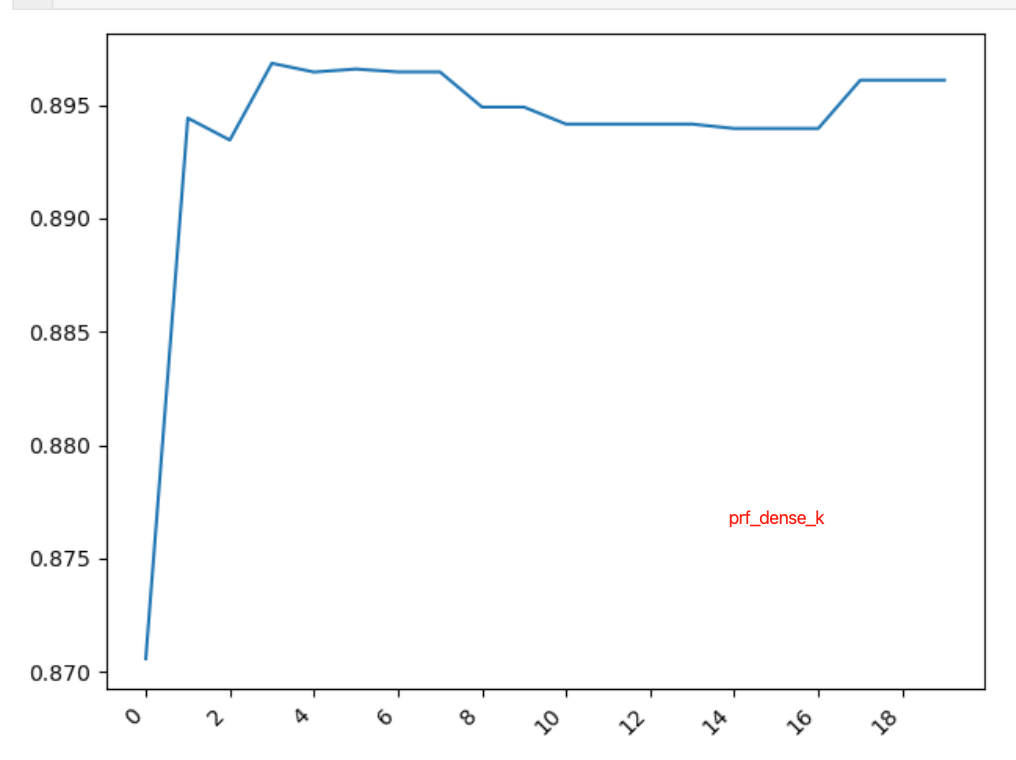
- 4. m_extra = 14 performs best; larger values of m_extra generally lead to more stable results.
  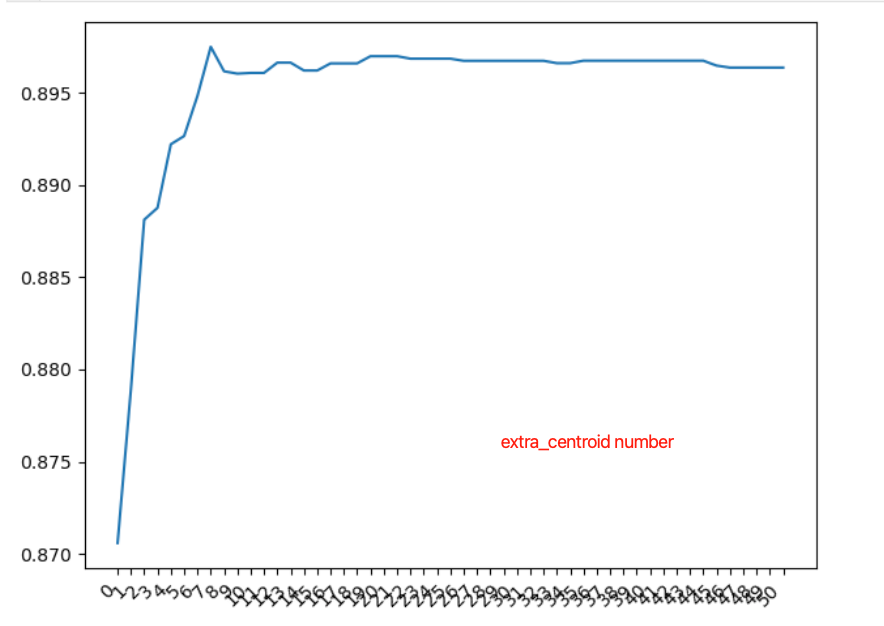
- limitation:
-> ndcg@10 and mrr@10 doesn't change much 

- Further study the result files for a centroid boost retriever, with the qrels, and calculate the highest ndcg@10 score that the passags list can attain, we see that ndcg@10 oracle = 0.9942, but with maxsim scoring, ndcg@10 = 0.7382. Therefore, a better rescoring method is needed to promote the high quality docs to the top is critical. 

In [57]:
import numpy as np, pandas as pd, pyterrier as pt


def oracle_rerank_df(df, qrels, doc_col='docno'):
    # 左连接标注，未标注视为0
    m = df.merge(qrels[['qid', doc_col, 'label']], on=['qid', doc_col], how='left')
    m['label'] = m['label'].fillna(0).astype(float)

    # 以 label 为主排序（原 score 只作细粒度tie-break）
    if 'score' in m:
        s = m['score'].astype(float).values
        s = (s - s.min()) / (s.max() - s.min() + 1e-12)
        m['score'] = m['label'] + 1e-6 * s
    else:
        m['score'] = m['label']

    m = m.sort_values(['qid','score'], ascending=[True, False])
    m['rank'] = m.groupby('qid').cumcount()
    return m


# 构造混合 PRF 的 CRB
crb_hybrid =  centroid_recall_boost_dynamic_hybrid(
    factory,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)
df = crb_hybrid(topics2019)

df_oracle = oracle_rerank_df(df, qrels2019, doc_col='docno')
# %IDCG
pt.Evaluate(
    df_oracle, qrels2019,
    metrics = [RR(rel=2), nDCG@10, nDCG@100, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
)

{'RR(rel=2)': 1.0,
 'nDCG@10': 0.9942089060662466,
 'nDCG@100': 0.9319890289027771,
 'AP(rel=2)': 0.8989203284203806,
 'R(rel=2)@10': 0.4487818635257204,
 'R(rel=2)@100': 0.8466878656857009,
 'R(rel=2)@1000': 0.8989203284203806}

# TREC 2020

In [43]:
boost_mmr_hybrid = centroid_recall_boost_dynamic_hybrid(
    factory,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)
plaid_e2e = factory.plaid_end_to_end(k=1000)
from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e, boost_mmr_hybrid],
    topics2020,
    qrels2020,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid-C-dl20','hybrid-freq'],verbose = True
)

res1

pt.Experiment: 100%|██████████████████████████| 2/2 [00:43<00:00, 21.77s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid-C-dl20,0.842306,0.740983,0.696068,0.766168,0.526206,0.402467,0.770992,0.904436
1,hybrid-freq,0.842306,0.740983,0.697952,0.771850,0.527571,0.402467,0.772661,0.910338


In [34]:
boost_mmr_hybrid = centroid_recall_boost_dynamic_hybrid(
    factory,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)

plaid_e2e = factory.plaid_end_to_end(k=1000)
from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e, boost_mmr_hybrid],
    topics2020,
    qrels2020,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid-C-dl20','hybrid-mmr'],verbose = True
)

res1

pt.Experiment: 100%|██████████████████████████| 2/2 [00:30<00:00, 15.08s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid-C-dl20,0.842306,0.740983,0.696068,0.766168,0.526206,0.402467,0.770992,0.904436
1,hybrid-mmr,0.842306,0.740983,0.697501,0.769488,0.527373,0.402467,0.772417,0.908918


In [49]:
boost_freq_hybrid_b = centroid_recall_boost_dynamic_hybrid(
    factory_b,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)

boost_mmr_hybrid_b = centroid_recall_boost_dynamic_hybrid(
    factory_b,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)
plaid_e2e_b = factory_b.plaid_end_to_end(k=1000)

from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e_b, boost_freq_hybrid_b,boost_mmr_hybrid_b ],
    topics2020,
    qrels2020,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid_B','hybrid-freq','hybrid-mmr'],verbose = True
    # 可选：控制 per-query 显示/保存等
)

res1

pt.Experiment: 100%|██████████████████████████| 3/3 [00:45<00:00, 15.24s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid_B,0.842306,0.740983,0.693551,0.721302,0.516727,0.402467,0.758486,0.817500
1,hybrid-freq,0.842306,0.740983,0.698432,0.766980,0.526527,0.402467,0.770284,0.898821
2,hybrid-mmr,0.842306,0.740983,0.698639,0.766836,0.526672,0.402467,0.772685,0.902334


In [54]:
boost_freq_hybrid_a = centroid_recall_boost_dynamic_hybrid(
    factory_a,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)

boost_mmr_hybrid_a = centroid_recall_boost_dynamic_hybrid(
    factory_a,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)
plaid_e2e_a = factory_a.plaid_end_to_end(k=1000)

from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e_a, boost_freq_hybrid_a,boost_mmr_hybrid_a ],
    topics2020,
    qrels2020,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid_A','hybrid-freq','hybrid-mmr'],verbose = True
    # 可选：控制 per-query 显示/保存等
)

res1

pt.Experiment: 100%|██████████████████████████| 3/3 [00:43<00:00, 14.53s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid_A,0.842306,0.741120,0.639783,0.628087,0.484613,0.402754,0.696646,0.696646
1,hybrid-freq,0.842306,0.741980,0.699688,0.765209,0.529370,0.403272,0.770915,0.890704
2,hybrid-mmr,0.842306,0.741548,0.700882,0.764674,0.528302,0.402467,0.775601,0.891778


# TREC dlhard

In [36]:
# 

In [44]:
boost_mmr_hybrid = centroid_recall_boost_dynamic_hybrid(
    factory,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=50, k=1000,
)
plaid_e2e = factory.plaid_end_to_end(k=1000)
from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e, boost_mmr_hybrid],
    topics_dlhard,
    qrels_dlhard,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid-C-dlhard','hybrid-freq'],verbose = True
)

res1

pt.Experiment: 100%|██████████████████████████| 2/2 [00:41<00:00, 21.00s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid-C-dlhard,0.581308,0.414594,0.460658,0.535359,0.272702,0.289868,0.641487,0.838944
1,hybrid-freq,0.581300,0.414594,0.460955,0.540451,0.272953,0.289868,0.642132,0.857062


In [38]:
boost_mmr_hybrid = centroid_recall_boost_dynamic_hybrid(
    factory,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)

plaid_e2e = factory.plaid_end_to_end(k=1000)
from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e, boost_mmr_hybrid],
    topics_dlhard,
    qrels_dlhard,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid-C-dlhard','hybrid-mmr'],verbose = True
)

res1

pt.Experiment: 100%|██████████████████████████| 2/2 [00:30<00:00, 15.17s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid-C-dlhard,0.581308,0.414594,0.460658,0.535359,0.272702,0.289868,0.641487,0.838944
1,hybrid-mmr,0.581300,0.414594,0.460893,0.541286,0.273213,0.289868,0.642132,0.865935


In [50]:
boost_freq_hybrid_b = centroid_recall_boost_dynamic_hybrid(
    factory_b,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)

boost_mmr_hybrid_b = centroid_recall_boost_dynamic_hybrid(
    factory_b,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.5, k=1000,
)
plaid_e2e_b = factory_b.plaid_end_to_end(k=1000)

from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e_b, boost_freq_hybrid_b,boost_mmr_hybrid_b ],
    topics_dlhard,
    qrels_dlhard,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=['plaid_B','hybrid-freq','hybrid-mmr'],verbose = True
    # 可选：控制 per-query 显示/保存等
)

res1

pt.Experiment: 100%|██████████████████████████| 3/3 [00:46<00:00, 15.51s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000
0,plaid_B,0.580946,0.416281,0.456205,0.494191,0.267169,0.290513,0.629263,0.728082
1,hybrid-freq,0.581077,0.414594,0.457661,0.537395,0.272085,0.289868,0.629798,0.848673
2,hybrid-mmr,0.581087,0.414594,0.459614,0.539777,0.273312,0.289868,0.637132,0.860606


In [60]:
boost_freq_hybrid_a = centroid_recall_boost_dynamic_hybrid(
    factory_a,
    strategy='freq',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14, k=1000,
)

boost_mmr_hybrid_a = centroid_recall_boost_dynamic_hybrid(
    factory_a,
    strategy='mmr',
    sparse_retriever = bm25,
    prf_k_dense = 3, prf_k_sparse = 3,w_dense=0.5, w_sparse=0.5,
    m_extra=14,  mmr_lambda=0.7, k=1000,
)
plaid_e2e_a = factory_a.plaid_end_to_end(k=1000)

from pyterrier.measures import *
res1 = pt.Experiment(
    [plaid_e2e_a, boost_freq_hybrid_a,boost_mmr_hybrid_a ],
    topics_dlhard,
    qrels_dlhard,
    eval_metrics=[RR(rel=2), nDCG@10, nDCG@100,nDCG@1000, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000,"mrt"],
    names=['plaid_A','hybrid-freq','hybrid-mmr'],verbose = True
    # 可选：控制 per-query 显示/保存等
)

res1

pt.Experiment: 100%|██████████████████████████| 3/3 [00:45<00:00, 15.19s/system]


,name,RR(rel=2),nDCG@10,nDCG@100,nDCG@1000,AP(rel=2),R(rel=2)@10,R(rel=2)@100,R(rel=2)@1000,mrt
0,plaid_A,0.580589,0.417828,0.419273,0.415717,0.244422,0.292252,0.548016,0.548016,33.306482
1,hybrid-freq,0.581123,0.415671,0.458926,0.534820,0.274731,0.290738,0.635529,0.837132,420.509485
2,hybrid-mmr,0.581351,0.415432,0.461136,0.535811,0.272913,0.289868,0.639100,0.831311,453.066391


# Parameter study

In [ ]:
plaid_e2e = factory.plaid_end_to_end(k=1000)
systems = [plaid_e2e]
names = ['plaid']
for  m in range(1,20):
    systems.append(centroid_recall_boost(factory, prf_k=m, m_extra=50, rounds=1,k=1000))
    names.append(f'boost_prf_k={m}')
from pyterrier.measures import *
res_m = pt.Experiment(
    systems,
    topics2019, qrels2019,
    eval_metrics = [RR(rel=2), nDCG@10, nDCG@100, AP(rel=2),R(rel=2)@10, R(rel=2)@100, R(rel=2)@1000],
    names=names, verbose = True
)
res_m
